In [1]:
import numpy as np
from pprint import pprint
import pickle
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
from scipy.sparse.linalg import svds
from resampy import resample
from sklearn.decomposition import FastICA, PCA
import mne
import pywt

In [2]:
def pol2cart(rho, phi, z=None):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    if z is not None:
        return x, y, z
    print(rho, phi, z)
    return x, y

In [3]:
%matplotlib widget
LINE_WIDTH = 2
FONT_SIZE = 12
col = np.array(
    [
        [1, 0, 0],
        [0, 0, 1],
        [0, 0.8, 0],
        [0.4, 0.4, 0],
        [0, 0.8, 0.8],
        [0.4, 0, 0.8],
        [0.8, 0.4, 1],
        [0.4, 0.4, 1],
    ]
)

In [7]:
with open("temp_with_noise_MA_SNR=0.pkl", "rb") as f:
    temp_file = pickle.load(f)

NB_FOETUSES = len(temp_file["f_model"])
fs = temp_file["params"]["fs"]
fs_new = 250
n = temp_file["params"]["n"]
tm = np.arange(1 / fs, n / fs + 1 / fs, 1 / fs)

print(f"Original fs = {fs}")
print(f"New fs = {fs_new}")
print(f"Time = {n / fs} s")
print(f"SNR FECG/MECG = {temp_file['params']['SNRfm']}")
print(f"SNR MECG/Noise = {temp_file['params']['SNRmn']}")

Original fs = 1000
New fs = 250
Time = 60.0 s
SNR FECG/MECG = -9
SNR MECG/Noise = 0


In [ ]:
temp_file["f_model"][0]["H"]

array([[-4.01682947,  4.00383159,  3.92994375],
       [-3.65656517,  0.61810308,  0.48330513],
       [ 2.71908298,  8.62681347,  1.87627742],
       [-6.52937173,  6.50824364, -2.45045551],
       [-1.51075207,  0.36934581,  0.03264646]])

In [6]:
used_electrodes = temp_file["params"]["elpos"]
maternal_heart = temp_file["params"]["mheart"]
foetus_heart = temp_file["params"]["fheart"]

In [41]:
def compare_cycles(cycleA, cycleB, thres):
    """
    Cross-correlation measure to compare if new ecg cycle matches template.
    """
    match = 0
    bins = cycleA.shape[0]

    coeff = np.sqrt(
        np.abs((cycleA - np.mean(cycleA)) @ (cycleB - np.mean(cycleB)))
        / (bins * np.std(cycleA) * np.std(cycleB))
    )

    if coeff > thres:
        match = 1

    return match

In [42]:
def fecgsyn_ts_extraction(peaks, ecg, nbCycles, NbPC, fs):
    NB_MQRS = len(peaks)

    ecg_temp = np.zeros(len(ecg))

    ecg_buff = np.zeros((round(0.7 * fs), nbCycles))

    Pstart = int(np.ceil(0.25 * fs) - 1)
    Tstop = int(np.floor(0.45 * fs))

    indMQRSpeaks = np.where(peaks > Pstart)[0]

    # --- build initial buffer ---
    for cc in range(nbCycles):
        peak_nb = peaks[indMQRSpeaks[cc + 1]]  # +1 to ensure full cycles
        ecg_buff[:, cc] = ecg[peak_nb - Pstart : peak_nb + Tstop + 1]

    TECG = np.median(ecg_buff, axis=1)

    U, _, _ = svds(ecg_buff, k=NbPC)

    # == MECG cancellation
    for qq in range(NB_MQRS):
        if peaks[qq] > Pstart and (len(ecg) - peaks[qq]) > Tstop:
            if qq % 10 == 0:
                # allow adaptation of PCA basis
                U, _, _ = svds(ecg_buff, k=NbPC)

            segment = ecg[peaks[qq] - Pstart : peaks[qq] + Tstop + 1]

            X_out = segment @ (U @ U.T)

            ecg_temp[peaks[qq] - Pstart : peaks[qq] + Tstop + 1] = X_out

            if qq > nbCycles:
                Match = compare_cycles(
                    TECG, ecg[peaks[qq] - Pstart : peaks[qq] + Tstop + 1], 0.8
                )

                if Match:
                    ecg_buff = np.roll(ecg_buff, -1, axis=1)
                    ecg_buff[:, -1] = ecg[peaks[qq] - Pstart : peaks[qq] + Tstop + 1]
                    TECG = np.median(ecg_buff, axis=1)

        # == managing borders
        elif peaks[qq] <= Pstart:
            n = len(ecg_temp[: peaks[qq] + Tstop])
            m = len(TECG)

            ecg_temp[: peaks[qq] + Tstop + 1] = TECG[m - n :]

        elif (len(ecg) - peaks[qq]) < Tstop:
            part = ecg_temp[peaks[qq] - Pstart :]
            ecg_temp[peaks[qq] - Pstart :] = TECG[: len(part)]

    # residual
    residual = ecg - ecg_temp

    return residual, ecg_temp

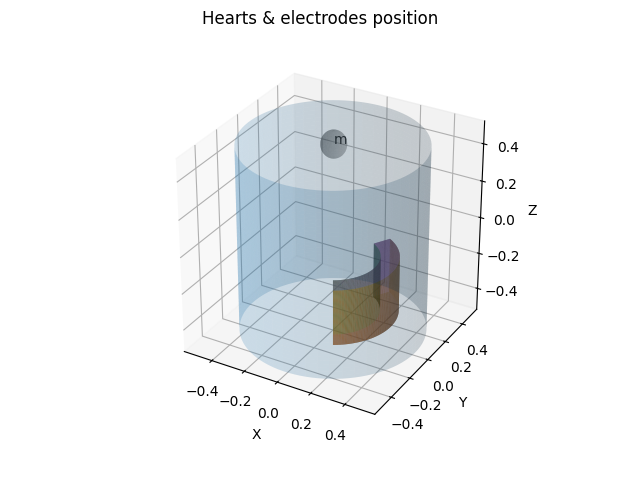

In [ ]:
phi = np.linspace(0, 2 * np.pi, 100)
z = np.linspace(z_min, z_max, 100)
phi, z = np.meshgrid(phi, z)
x = R_cyl * np.cos(phi)
y = R_cyl * np.sin(phi)


fig_3d = plt.figure()
fig_3d.suptitle("Hearts & electrodes position")
ax_3d = fig_3d.add_subplot(projection="3d")

ax_3d.plot_surface(x, y, z, alpha=0.2)

theta_min, theta_max = -np.pi / 3, np.pi / 3
z_min, z_max = -0.4, -0.1
r_min, r_max = 0.25, 0.35

# сетки
theta = np.linspace(theta_min, theta_max, 100)
z = np.linspace(z_min, z_max, 100)
theta_grid, z_grid = np.meshgrid(theta, z)

# --- внешняя поверхность ---
r = r_max
x = r * np.cos(theta_grid)
y = r * np.sin(theta_grid)
ax_3d.plot_surface(x, y, z_grid, alpha=0.6)

# --- внутренняя поверхность ---
r = r_min
x = r * np.cos(theta_grid)
y = r * np.sin(theta_grid)
ax_3d.plot_surface(x, y, z_grid, alpha=0.6)

# --- боковые стенки (theta = const) ---
z_side = np.linspace(z_min, z_max, 100)
r_side = np.linspace(r_min, r_max, 50)
z_side, r_side = np.meshgrid(z_side, r_side)

# theta = theta_min
x = r_side * np.cos(theta_min)
y = r_side * np.sin(theta_min)
ax_3d.plot_surface(x, y, z_side, alpha=0.6)

# theta = theta_max
x = r_side * np.cos(theta_max)
y = r_side * np.sin(theta_max)
ax_3d.plot_surface(x, y, z_side, alpha=0.6)

# --- крышки по z ---
theta_cap, r_cap = np.meshgrid(theta, np.linspace(r_min, r_max, 50))

# z = z_min
x = r_cap * np.cos(theta_cap)
y = r_cap * np.sin(theta_cap)
z = np.full_like(x, z_min)
ax_3d.plot_surface(x, y, z, alpha=0.6)

# z = z_max
z = np.full_like(x, z_max)
ax_3d.plot_surface(x, y, z, alpha=0.6)
# for i, (x, y, z) in enumerate(used_electrodes):
#     ax_3d.scatter(x, y, z, s=80)
#     ax_3d.text(x, y, z, str(i + 1))

plot_sphere(maternal_heart, R_heart, "m")

# for i in range(NB_FOETUSES):
#     plot_sphere(foetus_heart[i], R_heart, f"f_{i + 1}")

# plot_sphere([np.pi / 5, 0.35, -0.3], R_heart, f"f_{i + 1}")
ax_3d.set_xlabel("X")
ax_3d.set_ylabel("Y")
ax_3d.set_zlabel("Z")

ax_3d.set_box_aspect([1, 1, 1])
plt.ion()
plt.show()

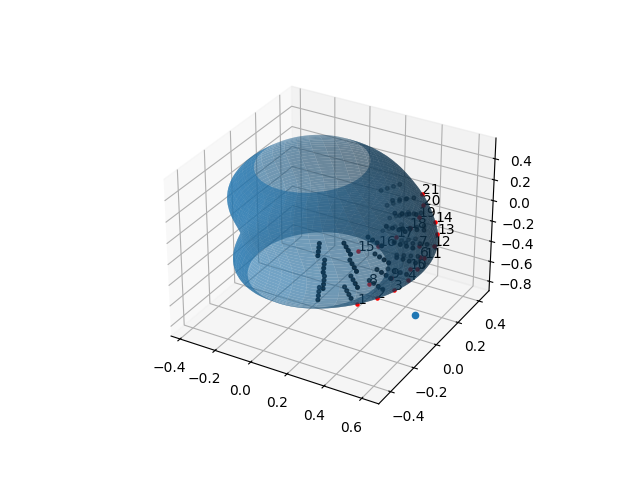

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# параметры
R_chest = 0.35
R_hips = 0.4
R_belly = 0.1
%matplotlib widget
LINE_WIDTH = 2
FONT_SIZE = 12
col = np.array(
    [
        [1, 0, 0],
        [0, 0, 1],
        [0, 0.8, 0],
        [0.4, 0.4, 0],
        [0, 0.8, 0.8],
        [0.4, 0, 0.8],
        [0.8, 0.4, 1],
        [0.4, 0.4, 1],
    ]
)


def pol2cart(rho, phi, z=None):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    if z is not None:
        return x, y, z
    print(rho, phi, z)
    return x, y


# форма
a = 8.0
c = 6.0

v0 = -0.1  # центр живота
w = 0.3

u = np.linspace(0, 2 * np.pi, 120)
v = np.linspace(-0.5, 0.5, 120)
u, v = np.meshgrid(u, v)

R_base = R_chest * np.exp(-a * (v - 0.3) ** 2) + R_hips * np.exp(-c * (v + 0.3) ** 2)

belly_profile = 1 / (1 + ((v - v0) / w) ** 4)
front = np.maximum(0, np.cos(u))

belly = R_belly * belly_profile * front

R = R_base + belly

x = R * np.cos(u)
x += 0.1 * np.exp(-10 * (v - v0) ** 2)
y = R * np.sin(u)
z = v
R_heart = 0.07
# # график
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
# f_hearts = [
#     [-np.pi / 4, 0.4, -0.2],
#     [0, 0.4, -0.2],
# ]
ax.plot_surface(x, y, z, alpha=0.6)

# # --- ПАРАМЕТРЫ ТОЧЕК ---
n_phi_hearts = 7
n_z_hearts = 4

phi_hearts = np.linspace(-np.pi / 3, np.pi / 3, n_phi_hearts)
z_lin_hearts = np.linspace(-0.3, 0.1, n_z_hearts)
n_r = 4

d_vals = np.linspace(0.05, 0.15, n_r)  # расстояние от поверхности

phi_3d, z_3d, d_3d = np.meshgrid(phi_hearts, z_lin_hearts, d_vals, indexing="ij")

R_base_pts = R_chest * np.exp(-a * (z_3d - 0.3) ** 2) + R_hips * np.exp(
    -c * (z_3d + 0.3) ** 2
)

belly_profile_pts = 1 / (1 + ((z_3d - v0) / w) ** 4)
front_pts = np.maximum(0, np.cos(phi_3d))
belly_pts = R_belly * belly_profile_pts * front_pts

R_surface = R_base_pts + belly_pts

R_inner = R_surface - d_3d

R_inner = np.maximum(R_inner, 0)

x_center = 0.1 * np.exp(-10 * (z_3d - v0) ** 2)

x_inner = x_center + R_inner * np.cos(phi_3d)
y_inner = R_inner * np.sin(phi_3d)
z_inner = z_3d

ax.scatter(x_inner, y_inner, z_inner, s=7, color="k")
phi_flat = phi_3d.flatten()
R_flat = R_inner.flatten()
z_flat = z_3d.flatten()

points_inner_cyl = np.column_stack((phi_flat, R_flat, z_flat))
# первые две итерации от -пи/4 до пи/4
n_phi_pts = 7  # количество по углу
n_z_pts = 3
z_lin_pts = np.linspace(-0.35, 0.15, n_z_pts)
phi_pts = np.linspace(-np.pi / 5, np.pi / 5, n_phi_pts)
phi_pts, z_lin_pts = np.meshgrid(phi_pts, z_lin_pts)

# --- ВОССТАНАВЛИВАЕМ РАДИУС (ТА ЖЕ ФОРМУЛА!) ---

# базовая форма
R_base_pts = R_chest * np.exp(-a * (z_lin_pts - 0.3) ** 2) + R_hips * np.exp(
    -c * (z_lin_pts + 0.3) ** 2
)

# профиль живота (тот же!)
belly_profile_pts = 1 / (1 + ((z_lin_pts - v0) / w) ** 4)

# только спереди
front_pts = np.maximum(0, np.cos(phi_pts))

# живот
belly_pts = R_belly * belly_profile_pts * front_pts

# итоговый радиус
R_pts = R_base_pts + belly_pts

# --- ПЕРЕВОД В ДЕКАРТОВЫ ---
x_pts = R_pts * np.cos(phi_pts)
x_pts += 0.1 * np.exp(-10 * (z_lin_pts - v0) ** 2)
y_pts = R_pts * np.sin(phi_pts)
z_pts = z_lin_pts

x_center = 0.1 * np.exp(-10 * (z_lin_pts - v0) ** 2)
R_true = np.sqrt(x_pts**2 + y_pts**2)
phi_true = np.arctan2(y_pts, x_pts)
phi_flat = phi_true.flatten()
r_flat = R_true.flatten()
z_flat = z_lin_pts.flatten()

points_cyl = np.column_stack((phi_flat, r_flat, z_flat))

for i, (phi, r, z) in enumerate(points_cyl):
    x, y, z = pol2cart(r, phi, z)
    ax.scatter(x, y, z, s=5, color="r")
    ax.text(x, y, z, str(i + 1))


x, y, z = pol2cart(points_cyl[4][1], points_cyl[4][0], -0.8)
ax.scatter(x, y, z, s=20)
plt.ion()
plt.show()

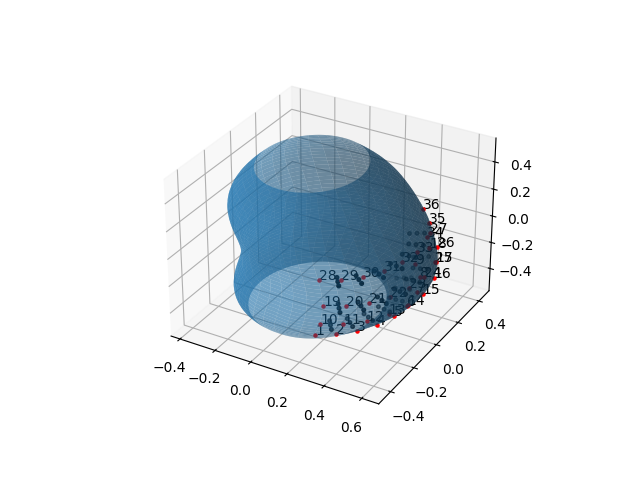

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# параметры
R_chest = 0.35
R_hips = 0.4
R_belly = 0.1
%matplotlib widget


def plot_sphere(center_cyl, radius, label):
    phi_c, r_c, z_c = center_cyl
    xc, yc, zc = pol2cart(r_c, phi_c, z_c)

    u = np.linspace(0, 2 * np.pi, 120)
    v = np.linspace(0, np.pi, 120)
    u, v = np.meshgrid(u, v)

    xs = xc + radius * np.cos(u) * np.sin(v)
    ys = yc + radius * np.sin(u) * np.sin(v)
    zs = zc + radius * np.cos(v)

    ax.plot_surface(xs, ys, zs, color="r", alpha=1)
    ax.text(xc, yc, zc, label)


def pol2cart(rho, phi, z=None):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    if z is not None:
        return x, y, z
    return x, y


# форма
a = 8.0
c = 6.0

v0 = -0.1  # центр живота
w = 0.3

u = np.linspace(0, 2 * np.pi, 120)
v = np.linspace(-0.5, 0.5, 120)
u, v = np.meshgrid(u, v)

R_base = R_chest * np.exp(-a * (v - 0.3) ** 2) + R_hips * np.exp(-c * (v + 0.3) ** 2)

belly_profile = 1 / (1 + ((v - v0) / w) ** 4)
front = np.maximum(0, np.cos(u))

belly = R_belly * belly_profile * front

R = R_base + belly

x = R * np.cos(u)
x += 0.1 * np.exp(-10 * (v - v0) ** 2)
y = R * np.sin(u)
z = v
R_heart = 0.07
# # график
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
# f_hearts = [
#     [-np.pi / 4, 0.4, -0.2],
#     [0, 0.4, -0.2],
# ]
ax.plot_surface(x, y, z, alpha=0.6)
# plot_sphere(maternal_heart, R_heart, "m")
# for i in range(len(f_hearts)):
#     plot_sphere(f_hearts[i], R_heart, f"f_{i + 1}")

# # --- ПАРАМЕТРЫ ТОЧЕК ---
n_phi_hearts = 7
n_z_hearts = 3

phi_hearts = np.linspace(-5 * np.pi / 18, np.pi / 6, n_phi_hearts)
z_lin_hearts = np.linspace(-0.35, 0.0, n_z_hearts)
n_r = 3
d_vals = np.linspace(0.04, 0.11, n_r)  # расстояние от поверхности

phi_3d, z_3d, d_3d = np.meshgrid(phi_hearts, z_lin_hearts, d_vals, indexing="ij")

R_base_pts = R_chest * np.exp(-a * (z_3d - 0.3) ** 2) + R_hips * np.exp(
    -c * (z_3d + 0.3) ** 2
)

belly_profile_pts = 1 / (1 + ((z_3d - v0) / w) ** 4)
front_pts = np.maximum(0, np.cos(phi_3d))
belly_pts = R_belly * belly_profile_pts * front_pts

R_surface = R_base_pts + belly_pts

R_inner = R_surface - d_3d

R_inner = np.maximum(R_inner, 0)

x_center = 0.1 * np.exp(-10 * (z_3d - v0) ** 2)

x_inner = x_center + R_inner * np.cos(phi_3d)
y_inner = R_inner * np.sin(phi_3d)
z_inner = z_3d

ax.scatter(x_inner, y_inner, z_inner, s=7, color="k")
phi_flat = phi_3d.flatten()
R_flat = R_inner.flatten()
z_flat = z_3d.flatten()

points_inner_cyl = np.column_stack((phi_flat, R_flat, z_flat))

n_phi_pts = 5  # количество по углу
n_z_pts = 3
z_low = np.linspace(-0.35, -0.1, n_z_pts)
z_high = np.array([0.07])
z_lin_pts = np.concatenate([z_low, z_high])
phi_right = np.linspace(-np.pi / 3, 0, 6)
phi_left = np.linspace(np.pi / 12, np.pi / 4, 3)
phi_pts = np.concatenate([phi_right, phi_left])
phi_pts, z_lin_pts = np.meshgrid(phi_pts, z_lin_pts)

# --- ВОССТАНАВЛИВАЕМ РАДИУС (ТА ЖЕ ФОРМУЛА!) ---

# базовая форма
R_base_pts = R_chest * np.exp(-a * (z_lin_pts - 0.3) ** 2) + R_hips * np.exp(
    -c * (z_lin_pts + 0.3) ** 2
)

# профиль живота (тот же!)
belly_profile_pts = 1 / (1 + ((z_lin_pts - v0) / w) ** 4)

# только спереди
front_pts = np.maximum(0, np.cos(phi_pts))

# живот
belly_pts = R_belly * belly_profile_pts * front_pts

# итоговый радиус
R_pts = R_base_pts + belly_pts

# --- ПЕРЕВОД В ДЕКАРТОВЫ ---
x_pts = R_pts * np.cos(phi_pts)
x_pts += 0.1 * np.exp(-10 * (z_lin_pts - v0) ** 2)
y_pts = R_pts * np.sin(phi_pts)
z_pts = z_lin_pts

x_center = 0.1 * np.exp(-10 * (z_lin_pts - v0) ** 2)
R_true = np.sqrt(x_pts**2 + y_pts**2)
phi_true = np.arctan2(y_pts, x_pts)
phi_flat = phi_true.flatten()
r_flat = R_true.flatten()
z_flat = z_lin_pts.flatten()

points_cyl = np.column_stack((phi_flat, r_flat, z_flat))
# # --- ОТРИСОВКА ---
# ax.scatter(x_pts, y_pts, z_pts, s=15)

for i, (phi, r, z) in enumerate(points_cyl):
    x, y, z = pol2cart(r, phi, z)
    ax.scatter(x, y, z, s=5, color="r")
    ax.text(x, y, z, str(i + 1))

plt.ion()
plt.show()

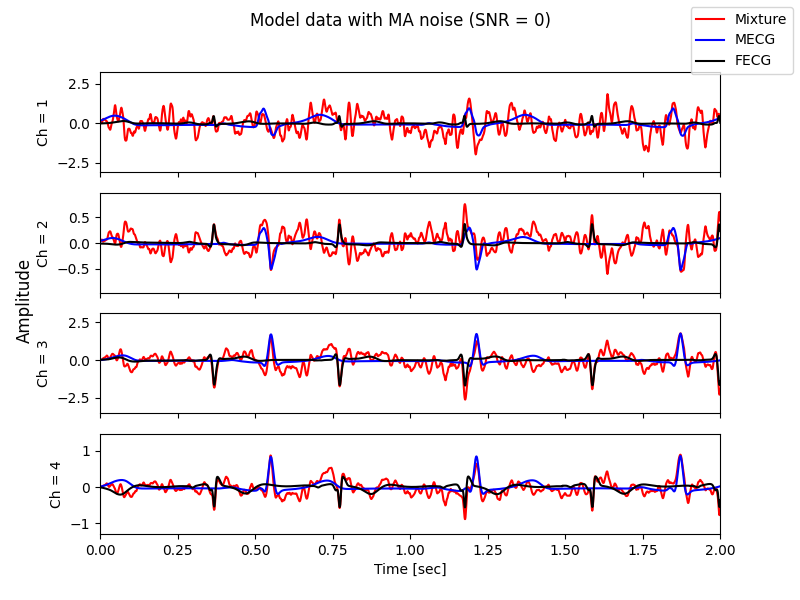

In [51]:
fig2, ax2 = plt.subplots(len(ch_my), 1, figsize=(8, 6), sharex=True)
fig2.suptitle("Model data with MA noise (SNR = 0)")

for i in range(len(ch_my)):
    ax2[i].plot(tm, temp_file["mixture"][i], "r")
    ax2[i].plot(tm, temp_file["mecg"][i], "b")
    ax2[i].plot(tm, temp_file["fecg"][0][i], "k")

    ax2[i].set_ylabel(f"Ch = {i + 1}")
    ax2[i].set_xlim(0, 2)

ax2[-1].set_xlabel("Time [sec]")
fig2.supylabel("Amplitude")
fig2.legend(["Mixture", "MECG", "FECG"])
fig2.savefig("MA_Noise_Signal.png")

In [45]:
Mhr = temp_file["params"]["mhr"]
ica = FastICA(n_components=len(ch_my), random_state=0)
sources_ica = ica.fit_transform(temp_file["mixture"].T)

# выбираем компоненту с максимальной энергией (обычно MECG)
energies = np.var(sources_ica, axis=0)
mecg_component = sources_ica[:, np.argmax(energies)]

# детекция MQRS
peaks, _ = find_peaks(
    mecg_component,
    distance=int((60 / Mhr) * fs * 0.8),
    height=np.std(mecg_component),
)

mqrs_locs = peaks

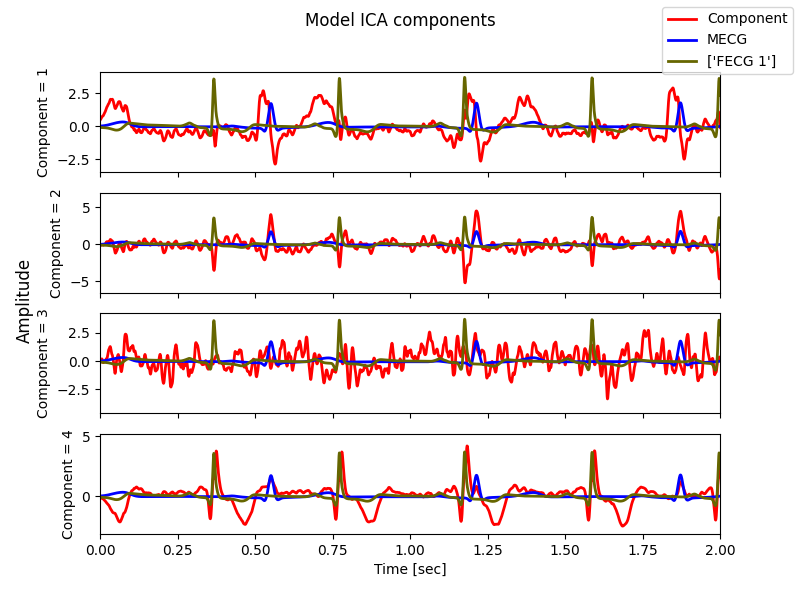

In [46]:
fig1, ax1 = plt.subplots(len(sources_ica.T), 1, figsize=(8, 6), sharex=True)
fig1.suptitle("Model ICA components")

for i in range(len(sources_ica.T)):
    ax1[i].plot(tm, sources_ica.T[i], "r", linewidth=LINE_WIDTH)
    ax1[i].plot(tm, temp_file["mecg"][2, :], "b", linewidth=LINE_WIDTH)
    ax1[i].plot(
        tm,
        temp_file["fecg"][0][1, :] * 10,
        color=col[(0 + 3) % len(col)],
        linewidth=LINE_WIDTH,
    )
    ax1[i].set_ylabel(f"Component = {i + 1}")
    ax1[i].set_xlim(0, 2)

ax1[-1].set_xlabel("Time [sec]")
fig1.supylabel("Amplitude")
fig1.legend(["Component", "MECG", [f"FECG {fet + 1}" for fet in range(NB_FOETUSES)]])
fig1.savefig("ICA components.png")

In [47]:
id = np.argmin(energies)
tast = sources_ica.copy() * 0
tast[:, id] = sources_ica[:, 0]

aww = ica.inverse_transform(tast)

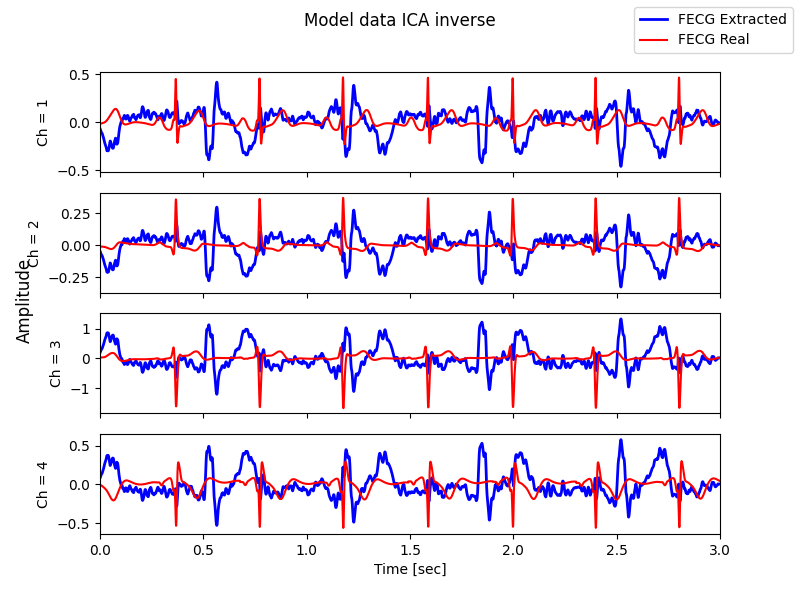

In [48]:
fig2, ax2 = plt.subplots(len(ch_my), 1, figsize=(8, 6), sharex=True)
fig2.suptitle("Model data ICA inverse")

for i in range(len(sources_ica.T)):
    ax2[i].plot(tm, aww[:, i], "b", linewidth=LINE_WIDTH)
    ax2[i].plot(tm, temp_file["fecg"][0][i, :], "r")

    ax2[i].set_ylabel(f"Ch = {i + 1}")
    ax2[i].set_xlim(0, 3)

ax2[-1].set_xlabel("Time [sec]")
fig2.supylabel("Amplitude")
fig2.legend(["FECG Extracted", "FECG Real"])
fig2.savefig("ICA_clear.png")

KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 179, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


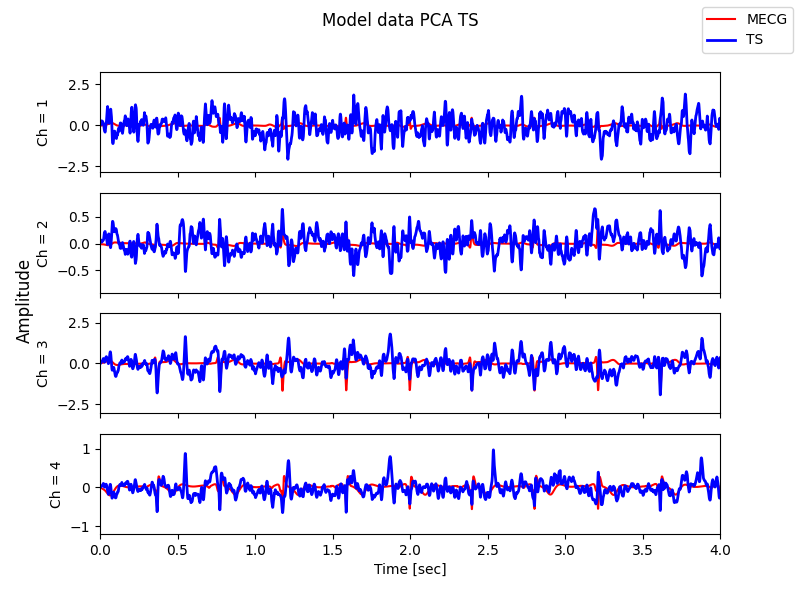

In [49]:
fig2, ax2 = plt.subplots(len(ch_my), 1, figsize=(8, 6), sharex=True)
fig2.suptitle("Model data PCA TS")

for i in range(len(ch_my)):
    a, b = fecgsyn_ts_extraction(mqrs_locs[1:], temp_file["mixture"][i], 20, 2, 1000)
    ax2[i].plot(tm, temp_file["fecg"][0][i, :], "r")
    ax2[i].plot(tm, a, "b", linewidth=LINE_WIDTH)

    ax2[i].set_ylabel(f"Ch = {i + 1}")
    ax2[i].set_xlim(0, 4)

ax2[-1].set_xlabel("Time [sec]")
fig2.supylabel("Amplitude")
fig2.legend(["MECG", "TS"])
fig2.savefig("TS.png")

In [ ]:
class FECGExtractor:
    def __init__(self, fs=1000):
        self.fs = fs

    # def run_ica(self, signals):

    #     return components

    def select_fetal_component(self, components):

        energies = np.var(sources_ica, axis=0)
        id = np.argmin(energies)

        return components[:, id]

    def swt_denoise(self, signal, wavelet="bior1.5", level=5):

        coeffs = pywt.swt(signal, wavelet, level=level)

        denoised_coeffs = []

        for cA, cD in coeffs:
            a = 2.7
            threshold_cA = a * 2 * np.var(np.abs(signal))
            cA = pywt.threshold(cA, threshold_cA, mode="hard")

            threshold_cD = a * 2 * np.var(np.abs(signal))
            cD = pywt.threshold(cD, threshold_cD, mode="hard")

            denoised_coeffs.append((cA, cD))

        reconstructed = pywt.iswt(denoised_coeffs, wavelet)

        return reconstructed

    def detect_r_peaks(self, signal):

        threshold = np.mean(signal) + 0.5 * np.std(signal)

        distance = int(0.3 * self.fs)

        peaks, _ = find_peaks(signal, height=threshold, distance=distance)

        return peaks

    def extract(self, aecg_signals):

        # components = self.run_ica(aecg_signals)
        ica = FastICA(n_components=len(aecg_signals.T), random_state=0)
        components = ica.fit_transform(aecg_signals)
        energies = np.var(components, axis=0)
        id = np.argmin(energies)
        fetal_raw = components[:, id]
        fetal_clean = self.swt_denoise(fetal_raw)
        tast = components.copy() * 0
        tast[:, id] = fetal_clean
        r_peaks = self.detect_r_peaks(fetal_clean)
        fetal_clean = ica.inverse_transform(tast)
        return fetal_clean, r_peaks, components

In [ ]:
trying = FECGExtractor(1000)

fecg_lal, r_peaks, components = trying.extract(temp_file["mixture"].T)

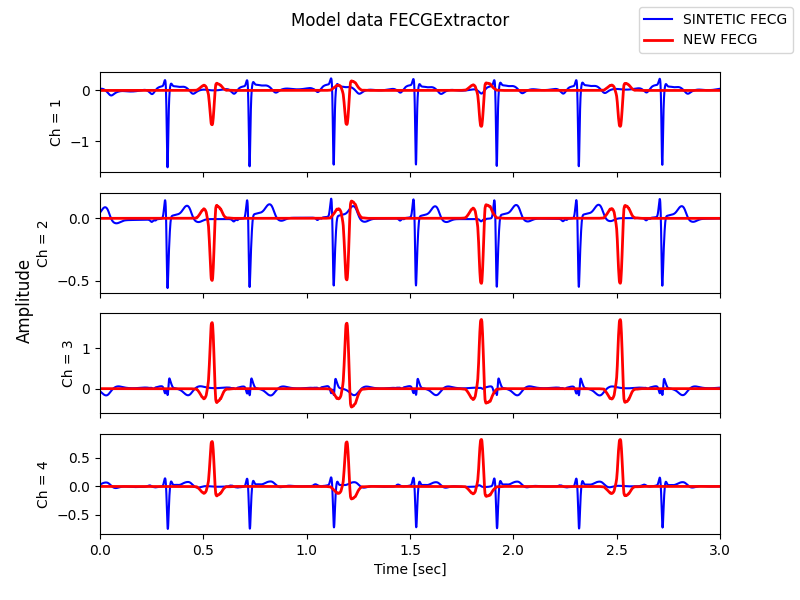

In [ ]:
fig2, ax2 = plt.subplots(len(ch_my), 1, figsize=(8, 6), sharex=True)
fig2.suptitle("Model data FECGExtractor")

for i in range(len(sources_ica.T)):
    ax2[i].plot(tm, temp_file["fecg"][0][i, :], "b")
    ax2[i].plot(tm, fecg_lal[:, i], "r", linewidth=LINE_WIDTH)
    ax2[i].set_ylabel(f"Ch = {i + 1}")
    ax2[i].set_xlim(0, 3)

ax2[-1].set_xlabel("Time [sec]")
fig2.supylabel("Amplitude")
fig2.legend(["SINTETIC FECG", "NEW FECG"])

Extracting EDF parameters from r01.edf...
Setting channel info structure...
Creating raw.info structure...


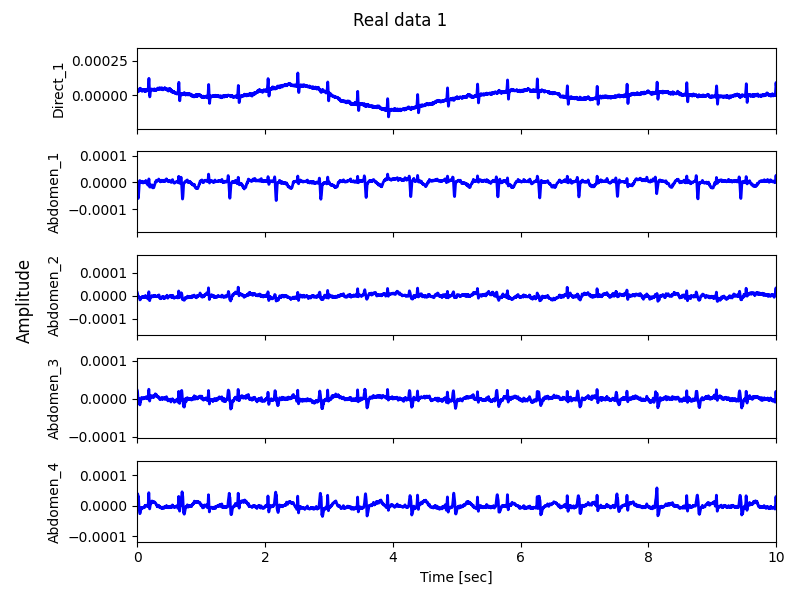

In [ ]:
record1 = mne.io.read_raw_edf("r01.edf")
ch_names = record1.ch_names
n = len(record1.get_data(picks=ch_names[0])[0])
x = np.linspace(0, 300, n)
fig_r1, ax_r1 = plt.subplots(len(ch_names), 1, figsize=(8, 6), sharex=True)
fig_r1.suptitle("Real data 1")

for i in range(len(ch_names)):
    ax_r1[i].plot(x, record1.get_data(picks=ch_names[i])[0], "b", linewidth=LINE_WIDTH)
    ax_r1[i].set_ylabel(f"{ch_names[i]}")

ax_r1[-1].set_xlim(0, 10)
ax_r1[-1].set_xlabel("Time [sec]")
fig_r1.supylabel("Amplitude")
fig_r1.tight_layout()

In [ ]:
ica_r1 = FastICA(n_components=4, random_state=0)
sources_ica_r1 = ica_r1.fit_transform(record1.get_data()[1:].T)

energies_r1 = np.var(sources_ica_r1, axis=0)
mecg_component_r1 = sources_ica_r1[:, np.argmax(energies_r1)]
id_r1 = np.argmin(energies_r1)
tast_r1 = sources_ica_r1.copy() * 0
tast_r1[:, id_r1] = sources_ica_r1[:, id_r1]

aww_r1 = ica_r1.inverse_transform(tast_r1)
# детекция MQRS
peaks_r, _ = find_peaks(
    mecg_component_r1,
    distance=int((60 / Mhr) * fs * 0.8),
    height=np.std(mecg_component_r1),
)
mqrs_locs_r = peaks_r

ValueError: x and y must have same first dimension, but have shapes (300000,) and (2, 300000)

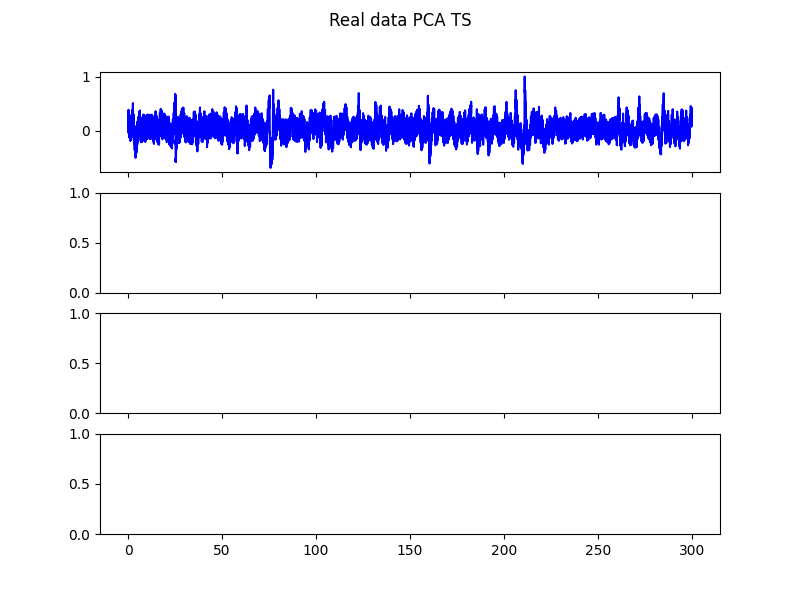

In [ ]:
ch_names_plot = ch_names[1:]
n = len(record1.get_data(picks=ch_names[0])[0])
x = np.linspace(0, 300, n)

fig2, ax2 = plt.subplots(len(ch_names_plot), 1, figsize=(8, 6), sharex=True)
fig2.suptitle("Real data PCA TS")

for i in range(len(ch_names_plot)):
    a = fecgsyn_ts_extraction(
        mqrs_locs_r[1:], record1.get_data(picks=ch_names_plot[i])[0], 20, 2, 1000
    )
    ax2[i].plot(
        x,
        record1.get_data(picks=ch_names[0])[0]
        / np.max(record1.get_data(picks=ch_names[0])[0]),
        "b",
    )
    ax2[i].plot(x, a / np.max(a), "r", linewidth=LINE_WIDTH)
    ax2[i].set_ylabel(f"Ch = {i + 1}")
    ax2[i].set_xlim(0, 3)

ax2[-1].set_xlabel("Time [sec]")
fig2.supylabel("Amplitude")
fig2.legend(["SINTETIC FECG", "NEW FECG"])

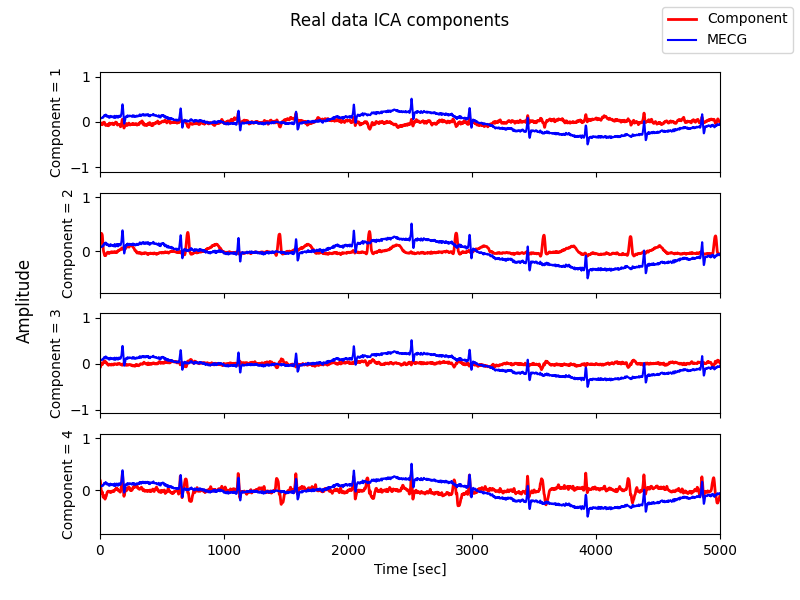

In [ ]:
fig1, ax1 = plt.subplots(len(sources_ica_r1.T), 1, figsize=(8, 6), sharex=True)
fig1.suptitle("Real data ICA components")

for i in range(len(sources_ica_r1.T)):
    ax1[i].plot(
        sources_ica_r1.T[i] / np.max(sources_ica_r1.T[i]), "r", linewidth=LINE_WIDTH
    )
    ax1[i].plot(
        record1.get_data(picks=ch_names[0])[0]
        / np.max(record1.get_data(picks=ch_names[0])[0]),
        "b",
    )
    ax1[i].set_ylabel(f"Component = {i + 1}")
    ax1[i].set_xlim(0, 5000)

ax1[-1].set_xlabel("Time [sec]")
fig1.supylabel("Amplitude")
fig1.legend(["Component", "MECG"])
fig1.savefig("ICA Components Real.png")

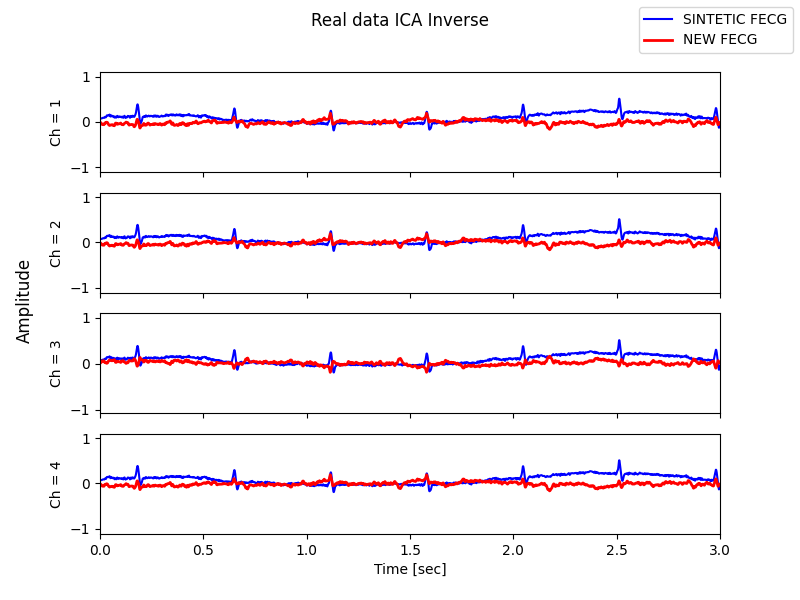

In [ ]:
fig2, ax2 = plt.subplots(len(ch_names_plot), 1, figsize=(8, 6), sharex=True)
fig2.suptitle("Real data ICA Inverse")


for i in range(len(ch_names_plot)):
    ax2[i].plot(
        x,
        record1.get_data(picks=ch_names[0])[0]
        / np.max(record1.get_data(picks=ch_names[0])[0]),
        "b",
    )
    ax2[i].plot(x, aww_r1[:, i] / np.max(aww_r1[:, i]), "r", linewidth=LINE_WIDTH)
    ax2[i].set_ylabel(f"Ch = {i + 1}")
    ax2[i].set_xlim(0, 3)

ax2[-1].set_xlabel("Time [sec]")
fig2.supylabel("Amplitude")
fig2.legend(["SINTETIC FECG", "NEW FECG"])